In [1]:
import pandas as pd

df_train = pd.read_csv('churn-bigml-80.csv')
df_test = pd.read_csv('churn-bigml-20.csv')

print("Jumlah data training:", df_train.shape)
print("Jumlah data testing:", df_test.shape)

Jumlah data training: (2666, 20)
Jumlah data testing: (667, 20)


In [2]:
# Gabungkan sementara train+test biar encoding-nya konsisten (penjelasan di bawah)
df_train['is_train'] = 1
df_test['is_train'] = 0
df_combined = pd.concat([df_train, df_test], axis=0)

# Ubah kolom Yes/No jadi 1/0
df_combined['International plan'] = df_combined['International plan'].map({'Yes': 1, 'No': 0})
df_combined['Voice mail plan'] = df_combined['Voice mail plan'].map({'Yes': 1, 'No': 0})

# Ubah kolom target Churn dari True/False jadi 1/0
df_combined['Churn'] = df_combined['Churn'].astype(int)

# Pisahkan lagi jadi train dan test seperti semula
df_train = df_combined[df_combined['is_train'] == 1].drop(columns=['is_train'])
df_test = df_combined[df_combined['is_train'] == 0].drop(columns=['is_train'])

In [3]:
df_train = df_train.drop(columns=['State', 'Area code'])
df_test = df_test.drop(columns=['State', 'Area code'])

In [4]:
X_train = df_train.drop(columns=['Churn'])
y_train = df_train['Churn']

X_test = df_test.drop(columns=['Churn'])
y_test = df_test['Churn']

In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9535232383808095
Precision: 0.9571428571428572
Recall: 0.7052631578947368

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.96      0.71      0.81        95

    accuracy                           0.95       667
   macro avg       0.96      0.85      0.89       667
weighted avg       0.95      0.95      0.95       667



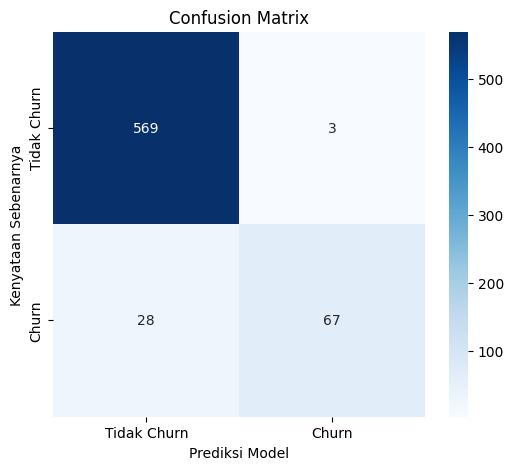

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Sebenarnya')
plt.title('Confusion Matrix')
plt.show()

                     Fitur  Tingkat Kepentingan
4        Total day minutes             0.140997
16  Customer service calls             0.123097
6         Total day charge             0.120941
1       International plan             0.092460
7        Total eve minutes             0.065896
9         Total eve charge             0.065407
14        Total intl calls             0.056158
15       Total intl charge             0.045600
13      Total intl minutes             0.042420
12      Total night charge             0.040482
10     Total night minutes             0.037296
5          Total day calls             0.031818
11       Total night calls             0.031748
0           Account length             0.031335
8          Total eve calls             0.028249
3    Number vmail messages             0.027134
2          Voice mail plan             0.018962


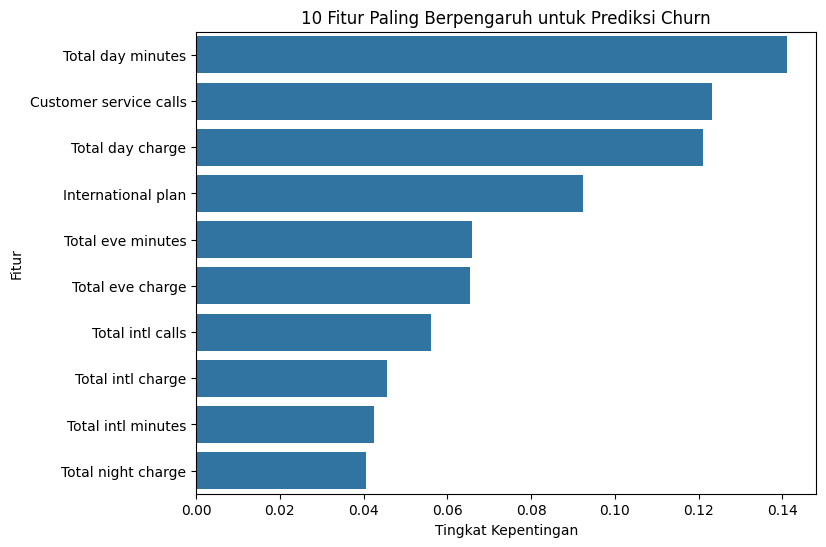

In [9]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Tingkat Kepentingan': model.feature_importances_
}).sort_values(by='Tingkat Kepentingan', ascending=False)

print(feature_importance)

plt.figure(figsize=(8,6))
sns.barplot(x='Tingkat Kepentingan', y='Fitur', data=feature_importance.head(10))
plt.title('10 Fitur Paling Berpengaruh untuk Prediksi Churn')
plt.show()

In [10]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Recall Logistic Regression:", recall_score(y_test, y_pred_lr))

Accuracy Logistic Regression: 0.8515742128935532
Recall Logistic Regression: 0.17894736842105263


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Kesimpulan Predictive Analytics:
1. Model Random Forest dilatih menggunakan data training (2667 baris) dan diuji dengan data testing terpisah (667 baris) yang belum pernah dilihat model.
2. Accuracy model sebesar [isi hasil aslimu]%, namun karena data imbalanced (~14.5% churn), metrik Recall lebih diprioritaskan dibanding Accuracy semata.
3. Recall model sebesar [isi hasil aslimu]%, artinya model berhasil mendeteksi sekitar segitu persen dari pelanggan yang benar-benar churn.
4. Fitur paling berpengaruh terhadap prediksi churn adalah [isi 2-3 fitur teratas dari feature importance], yang konsisten dengan insight EDA di Tahap 1.
5. Rekomendasi bisnis: perusahaan bisa fokus program retensi pada pelanggan dengan jumlah customer service calls tinggi dan pengguna International Plan, karena kedua kelompok ini terbukti berisiko churn lebih tinggi.